# Limpieza y análisis de datos de ventas
Este notebook documenta el proceso completo de limpieza de un dataset de ventas
de 4.215 registros (2024-2025) con los problemas habituales de un archivo
exportado sin control de calidad: categorías inconsistentes, columnas numéricas
almacenadas como texto, fechas en formatos mezclados, duplicados y valores
imposibles.

El objetivo no es solo dejar los datos utilizables, sino dejar constancia de
qué se corrigió y con qué criterio, de modo que los resultados sean auditables.

**Herramientas:** Python · pandas


## 1. Diagnóstico inicial

Antes de modificar nada, se inspecciona el estado del archivo: tipos de dato,
valores nulos, rangos numéricos y consistencia de las categorías. Limpiar sin
diagnosticar lleva a corregir lo evidente y pasar por alto lo importante.


In [1]:
import pandas as pd
df = pd.read_csv("ventas_sucio.csv")
df.head(20)

,Fecha,Producto,region,Canal,unidades_vendidas,Precio Unitario,ingreso
0,2025-10-03,Teclado,Norte,TIENDA,3,43.95,"€131,85"
1,05/12/2024,Monitor,Centro,Distribuidor,3,NaN,"547,35"
2,2025-02-07,Mouse,Este,Tienda,5,24.48,"122,40"
3,09/07/2024,Monitor,Centro,Tienda,2,219.98,"439,96 €"
4,2024-03-27,Mouse,Este,Online,4,25.64,"102,56 €"
5,2025-07-16,Auriculares,Centro,Tienda,1,91.96,"91,96 €"
6,NaN,Teclado,Oeste,Online,3,46.30,"138,90"
7,2025-10-14,Mouse,Norte,TIENDA,4,25.74,"102,96 €"
8,2024-10-25,Teclado,OESTE,Online,3,46.78,"€140,34"
9,2024-07-28,Mouse,Norte,distribuidor,4,21.22,"84,88 €"


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4215 entries, 0 to 4214
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Fecha              4139 non-null   object 
 1   Producto           4200 non-null   object 
 2   region             4177 non-null   object 
 3   Canal              4200 non-null   object 
 4   unidades_vendidas  4105 non-null   object 
 5   Precio Unitario    4099 non-null   float64
 6   ingreso            4200 non-null   object 
dtypes: float64(1), object(6)
memory usage: 230.6+ KB


In [3]:
df.describe()

,Precio Unitario
count,4099.000000
mean,104.806816
std,671.784108
min,0.000000
25%,25.765000
50%,52.860000
75%,90.160000
max,21631.220000


In [4]:
df["region"].value_counts()

region
Norte          1008
Centro          664
Oeste           653
Sur             628
Este            592
OESTE            59
NORTE            56
norte            47
oeste            46
centro           45
CENTRO           42
  Norte          41
SUR              37
sur              34
  Centro         33
?                32
ESTE             29
este             24
  Sur            24
  Oeste          22
desconocida      21
  Este           18
  SUR             3
  CENTRO          3
  oeste           3
  centro          3
  sur             2
  OESTE           2
  este            2
  norte           2
  NORTE           1
  ESTE            1
Name: count, dtype: int64

### Problemas detectados

- **6 de 7 columnas se leen como texto.** `ingreso` y `unidades_vendidas`
  contienen símbolos de moneda, comas decimales y marcadores de ausencia
  ("N/A", "-"), lo que impide cualquier cálculo hasta convertirlas.
- **La columna `region` presenta 28 valores distintos** cuando el negocio
  opera en 5 regiones. Las variantes por mayúsculas y espacios se contabilizan
  por separado y fragmentan los totales.
- **53 registros con región no informada**, codificada como "?" o
  "desconocida" en lugar de nulo.
- **Precios fuera de rango:** mínimo de 0 € y máximo de 21.631 € frente a una
  mediana de 52 €. La desviación estándar (671) supera seis veces a la media,
  señal de valores extremos que distorsionan cualquier promedio.
- **Nombres de columna inconsistentes**, con espacios sobrantes y mezcla de
  mayúsculas.
- **Filas duplicadas y filas completamente vacías.**

## 2. Normalización de los nombres de columna

Los encabezados llegan con espacios sobrantes y sin criterio de mayúsculas
(`"Producto "`, `"Precio Unitario"`, `"region"`). Un espacio final es invisible
al leer el archivo pero provoca errores al referenciar la columna.

Se unifican a minúsculas, sin espacios, separadas por guion bajo. Es el primer
paso porque todas las operaciones posteriores dependen de poder nombrar las
columnas de forma predecible.


In [5]:
df.columns = (df.columns
              .str.strip()
              .str.lower()
              .str.replace(" ", "_"))

df.columns

Index(['fecha', 'producto', 'region', 'canal', 'unidades_vendidas',
       'precio_unitario', 'ingreso'],
      dtype='object')

## 3. Eliminación de filas vacías y duplicados

Se eliminan las filas sin ningún dato (residuo habitual de exportación) y los
registros idénticos, que inflarían artificialmente los totales de ventas.

Se usa `dropna(how="all")` para borrar únicamente las filas totalmente vacías:
el comportamiento por defecto eliminaría cualquier fila con un solo nulo y
descartaría cientos de registros válidos.

Se registra el número de filas antes y después para dejar constancia del
volumen eliminado.

In [6]:
print("Antes:", len(df))

df = df.dropna(how="all")
df = df.drop_duplicates()

print("Después:", len(df))


Antes: 4215
Después: 4055


## 4. Unificación de categorías

`region`, `canal` y `producto` contienen el mismo valor escrito de varias
formas. Para pandas, "Norte", "NORTE" y "  norte " son tres categorías
distintas: los totales quedan repartidos y los gráficos muestran barras
duplicadas.

Se eliminan los espacios sobrantes y se normaliza la capitalización. Los
valores que representan ausencia de dato ("?", "desconocida") se convierten a
nulo, ya que no son una categoría real sino información no registrada.

In [7]:
# Normalizar formato: espacios sobrantes y capitalización
for col in ["region", "canal", "producto"]:
    df[col] = df[col].str.strip().str.capitalize()

# Los marcadores de ausencia no son una categoría: pasan a nulo
df["region"] = df["region"].replace(["?", "Desconocida", ""], pd.NA)

df["region"].value_counts(dropna=False)


region
Norte     1112
Centro     769
Oeste      754
Sur        702
Este       646
<NA>        49
NaN         23
Name: count, dtype: int64

In [8]:
df["canal"].value_counts()

canal
Online           1917
Tienda           1223
Distribuidor      681
On-line            82
Tienda fisica      60
Tienda física      52
Distrib.           40
Name: count, dtype: int64

In [9]:
equivalencias_canal = {
    "On-line": "Online",
    "Tienda fisica": "Tienda",
    "Tienda física": "Tienda",
    "Distrib.": "Distribuidor",
}

df["canal"] = df["canal"].replace(equivalencias_canal)
df["canal"].value_counts()

canal
Online          1999
Tienda          1335
Distribuidor     721
Name: count, dtype: int64

La normalización de formato resuelve las variantes por mayúsculas y espacios,
pero no las diferencias de denominación ("Distrib." frente a "Distribuidor",
"Tienda física" frente a "Tienda"). Estas requieren un mapeo explícito de
equivalencias: ninguna transformación automática puede deducir que dos
etiquetas distintas designan la misma categoría.

## 5. Conversión de columnas numéricas

`ingreso` y `unidades_vendidas` se almacenan como texto, lo que impide
cualquier cálculo: sumar una columna de texto concatena valores en lugar de
sumarlos. Es el problema más frecuente en archivos exportados y basta un único
valor no numérico para que toda la columna quede inutilizada.

**Ingreso.** Contiene el símbolo de moneda en posición variable (delante o
detrás), coma como separador decimal y punto como separador de miles, según la
convención española. La secuencia de limpieza respeta un orden obligatorio:
primero se elimina el separador de miles y solo después se sustituye la coma
decimal por punto. Invertir estos dos pasos generaría valores con dos puntos
—no interpretables como número— y su conversión devolvería nulos de forma
silenciosa.

**Unidades vendidas.** Los marcadores de ausencia ("N/A", "-", "null") no son
convertibles a número. Se emplea `errors="coerce"` para transformarlos en
nulos en lugar de interrumpir la ejecución: son datos no registrados y como
tales deben tratarse, no como ceros.

Se verifica el tipo de dato resultante en la misma celda y se cuantifican los
nulos generados, dado que toda conversión con `coerce` supone una pérdida
potencial de información que debe quedar documentada.


In [10]:
# Ingreso: quitar símbolo de moneda y normalizar separadores decimales
df["ingreso"] = (df["ingreso"]
                 .astype(str)
                 .str.replace("€", "", regex=False)
                 .str.strip()
                 .str.replace(".", "", regex=False)
                 .str.replace(",", ".", regex=False))

df["ingreso"] = pd.to_numeric(df["ingreso"], errors="coerce")

# Unidades: los marcadores de ausencia ("N/A", "-", "null") pasan a nulo
df["unidades_vendidas"] = pd.to_numeric(df["unidades_vendidas"], errors="coerce")

df.dtypes

fecha                 object
producto              object
region                object
canal                 object
unidades_vendidas    float64
precio_unitario      float64
ingreso              float64
dtype: object

In [11]:
df[["unidades_vendidas", "ingreso", "precio_unitario"]].isnull().sum()

unidades_vendidas    121
ingreso                0
precio_unitario       96
dtype: int64

La conversión no genera pérdida de información: `ingreso` se convierte en su
totalidad sin nulos, y los valores ausentes en `unidades_vendidas` (121) y
`precio_unitario` (96) ya estaban presentes en el archivo de origen. Los nulos
resultantes reflejan datos no registrados, no errores introducidos durante la
limpieza.

In [12]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
unidades_vendidas,3934.0,40.266141,567.304619,-4.00,2.00,3.00,4.00,11904.00
precio_unitario,3959.0,106.035961,683.435124,0.00,25.82,53.61,90.20,21631.22
ingreso,4055.0,231.807134,229.311484,19.08,85.04,152.02,277.92,1189.90


## 6. Tratamiento de valores imposibles

El diagnóstico revela valores que no pueden corresponder a operaciones reales:
cantidades negativas, cantidades tres órdenes de magnitud por encima de la
mediana, y precios de 0 € o superiores a 21.000 € en un catálogo cuya mediana
es de 53 €.

**Criterio de identificación.** No se trata de valores atípicos legítimos sino
de errores de captura, y la comprobación cruzada lo confirma: los registros con
cantidades desproporcionadas presentan ingresos dentro del rango normal. Una
venta de 11.904 unidades habría generado un ingreso de cientos de miles de
euros; el máximo del conjunto es de 1.190 €. Ambos datos no pueden ser ciertos
a la vez.

**Criterio de tratamiento.** Los valores afectados se convierten a nulo en
lugar de eliminar el registro completo: el resto de campos de esas filas
(fecha, producto, región, canal) es válido y su eliminación distorsionaría los
recuentos por categoría.

**Reconstrucción.** Dado que `ingreso` se ha conservado íntegro y responde a la
relación `unidades × precio`, los valores anulados se recuperan despejando la
incógnita a partir de los dos campos restantes. Esta redundancia permite
restituir información en lugar de descartarla.

**Umbrales aplicados.** Se fijan en 100 unidades y 1.000 € por situarse muy por
encima del comportamiento observado y muy por debajo de los valores anómalos.
En un encargo real estos límites deberían validarse con el cliente, dado que la
existencia de pedidos mayoristas legítimos alteraría el criterio.

In [13]:
import numpy as np

# Unidades: no puede haber ventas negativas ni cantidades fuera de escala
df.loc[df["unidades_vendidas"] < 1, "unidades_vendidas"] = np.nan
df.loc[df["unidades_vendidas"] > 100, "unidades_vendidas"] = np.nan

# Precio: ni gratis ni fuera del rango del catálogo
df.loc[df["precio_unitario"] <= 0, "precio_unitario"] = np.nan
df.loc[df["precio_unitario"] > 1000, "precio_unitario"] = np.nan

df.describe().T

,count,mean,std,min,25%,50%,75%,max
unidades_vendidas,3893.0,3.020807,1.419773,1.00,2.000,3.00,4.000,5.00
precio_unitario,3939.0,76.968614,62.494066,18.72,25.855,53.63,90.165,237.98
ingreso,4055.0,231.807134,229.311484,19.08,85.040,152.02,277.920,1189.90


In [14]:
# Recuperar unidades a partir de ingreso y precio
faltan_unidades = df["unidades_vendidas"].isna() & df["precio_unitario"].notna()
df.loc[faltan_unidades, "unidades_vendidas"] = (
    df.loc[faltan_unidades, "ingreso"] / df.loc[faltan_unidades, "precio_unitario"]
).round()

# Recuperar precio a partir de ingreso y unidades
faltan_precio = df["precio_unitario"].isna() & df["unidades_vendidas"].notna()
df.loc[faltan_precio, "precio_unitario"] = (
    df.loc[faltan_precio, "ingreso"] / df.loc[faltan_precio, "unidades_vendidas"]
).round(2)

df.describe().T

,count,mean,std,min,25%,50%,75%,max
unidades_vendidas,4048.0,3.018775,1.419670,1.00,2.0000,3.00,4.00,5.00
precio_unitario,4048.0,77.231144,63.818044,18.72,25.8375,53.72,90.19,839.56
ingreso,4055.0,231.807134,229.311484,19.08,85.0400,152.02,277.92,1189.90


In [15]:
df[df["precio_unitario"] > 400]

,fecha,producto,region,canal,unidades_vendidas,precio_unitario,ingreso
92,2024-03-06,Mouse,Centro,Online,1.0,839.56,839.56
3114,2024-12-08,Mouse,Norte,Distribuidor,2.0,439.14,878.29


In [16]:
df.groupby("producto")["precio_unitario"].describe()

,count,mean,std,min,25%,50%,75%,max
producto,,,,,,,,
Auriculares,1028.0,87.081625,7.049515,66.25,85.9475,89.245,91.580,136.44
Monitor,611.0,212.921931,15.708007,168.54,210.7750,217.350,222.545,237.98
Mouse,1130.0,25.362965,27.487226,18.72,24.0025,24.750,25.320,839.56
Teclado,826.0,44.072312,3.367935,34.50,43.7200,45.130,46.210,49.55
Webcam,453.0,61.705475,5.056902,49.13,61.0200,63.490,65.090,69.33


### Limitación de la reconstrucción por redundancia

La verificación detecta precios de 839 € y 439 € en el producto "Mouse", cuya
mediana se sitúa en 24,75 €. Ambos proceden del proceso de reconstrucción: su
precio se despejó a partir de un `ingreso` igualmente erróneo.

Esto evidencia el límite del método: reconstruir un campo a partir de otros
solo es fiable si el campo de origen es correcto.

**Corrección aplicada.** Un umbral global resulta insuficiente cuando los
productos tienen rangos de precio muy distintos: 839 € es imposible para un
ratón pero plausible para un monitor. Se sustituye por un umbral relativo a la
mediana de cada producto, que anula 3 registros —uno más de los identificados
mediante inspección visual— y reduce la desviación típica del producto "Mouse"
de 27,49 a 1,84, en línea con el resto del catálogo.

In [17]:
# Umbral relativo: ningún precio debería triplicar la mediana de su producto
mediana_producto = df.groupby("producto")["precio_unitario"].transform("median")
df.loc[df["precio_unitario"] > mediana_producto * 3, "precio_unitario"] = np.nan
df.groupby("producto")["precio_unitario"].describe()

,count,mean,std,min,25%,50%,75%,max
producto,,,,,,,,
Auriculares,1028.0,87.081625,7.049515,66.25,85.9475,89.245,91.580,136.44
Monitor,611.0,212.921931,15.708007,168.54,210.7750,217.350,222.545,237.98
Mouse,1127.0,24.170319,1.835644,18.72,23.9950,24.750,25.315,27.56
Teclado,826.0,44.072312,3.367935,34.50,43.7200,45.130,46.210,49.55
Webcam,453.0,61.705475,5.056902,49.13,61.0200,63.490,65.090,69.33


In [18]:
precio_canal = df.groupby(["producto", "canal"])["precio_unitario"].mean().unstack()
precio_canal["descuento_distribuidor_%"] = (
    (precio_canal["Distribuidor"] / precio_canal[["Online", "Tienda"]].mean(axis=1) - 1) * 100
).round(1)
precio_canal.round(2)

canal,Distribuidor,Online,Tienda,descuento_distribuidor_%
producto,,,,
Auriculares,74.12,90.17,89.86,-17.7
Monitor,179.89,219.48,218.69,-17.9
Mouse,20.48,24.94,24.94,-17.9
Teclado,37.26,45.44,45.53,-18.1
Webcam,52.63,64.15,64.14,-18.0


## 7. Normalización de fechas

La columna combina tres formatos distintos (ISO, europeo y estadounidense),
producto de una exportación sin criterio unificado. Se emplea `format="mixed"`
para interpretar cada registro individualmente y `dayfirst=True` para resolver
las fechas ambiguas conforme a la convención europea.

Este último parámetro resulta determinante: sin él, una fecha como 05/12/2024
se interpretaría como 5 de mayo en lugar de 5 de diciembre. El error no genera
ningún aviso y solo se manifiesta al agregar los datos por mes, distorsionando
todo el análisis de estacionalidad.

**Verificación.** El rango resultante abarca del 1 de enero de 2024 al 31 de
diciembre de 2025, coherente con el periodo esperado. La ausencia de fechas
fuera de ese intervalo confirma que ningún formato se ha interpretado
incorrectamente. Se registran 60 valores nulos (1,5%) correspondientes a
fechas ausentes en el origen.

In [19]:
df["fecha"] = pd.to_datetime(df["fecha"], format="mixed", dayfirst=True, errors="coerce")
df["fecha"].dtype


dtype('<M8[ns]')

In [20]:
df["fecha"].isna().sum()

np.int64(60)

In [21]:
print(df["fecha"].min(), "→", df["fecha"].max())

2024-01-01 00:00:00 → 2025-12-31 00:00:00


## 8. Política de precios por canal

El precio medio de cada producto varía de forma sistemática según el canal de
venta. El canal Distribuidor aplica un descuento de entre el 17,7% y el 18,2%
respecto a los canales minoristas, con una variación inferior a medio punto
porcentual en los cinco productos del catálogo.

**Interpretación.** La homogeneidad del descuento indica una política mayorista
establecida y no acuerdos negociados caso por caso: una tarifa diferenciada
aplicada de forma uniforme. Los canales Online y Tienda mantienen precios
prácticamente idénticos entre sí, lo que sugiere que la empresa no diferencia
precio entre sus canales propios y solo separa la venta mayorista de la
minorista.

**Implicación.** Un análisis de ingresos por canal que no considere esta
diferencia atribuiría al Distribuidor un menor rendimiento comercial cuando
parte de la diferencia se explica por la estructura de precios, no por el
volumen de ventas. La pregunta relevante para el negocio es si el volumen
adicional que aporta este canal compensa el margen cedido.

In [22]:
resumen_canal = df.groupby("canal").agg(
    operaciones=("ingreso", "count"),
    unidades=("unidades_vendidas", "sum"),
    ingreso_total=("ingreso", "sum"),
    ticket_medio=("ingreso", "mean")
).round(2)

resumen_canal

,operaciones,unidades,ingreso_total,ticket_medio
canal,,,,
Distribuidor,721,2187.0,142112.17,197.10
Online,1999,6014.0,471769.78,236.00
Tienda,1335,4019.0,326095.98,244.27


## 9. Rentabilidad del canal Distribuidor

El canal Distribuidor aporta 142.112 € (15% del ingreso total) frente a los
471.770 € del canal Online y los 326.096 € de Tienda.

**El volumen no justifica el descuento aplicado.** El número de unidades por
operación es prácticamente idéntico en los tres canales (3,03 en Distribuidor
frente a 3,01 en Online y Tienda). El canal mayorista no adquiere cantidades
superiores por transacción: adquiere la misma cantidad a un precio un 18%
inferior.

La diferencia de ticket medio —197,10 € frente a 236,00 € y 244,27 €— se
corresponde casi exactamente con el descuento aplicado, lo que descarta que
responda a un patrón de compra distinto.

**Recomendación.** Revisar las condiciones del canal Distribuidor. El descuento
mayorista se está aplicando sin la contrapartida de volumen que lo justifica.
Cabe evaluar si aporta valor por otras vías no contenidas en estos datos
—alcance geográfico, coste de adquisición de cliente, recurrencia— antes de
modificar la política. Con la información disponible, es el canal de menor
rendimiento por operación.

In [23]:
resumen_canal["unidades_por_operacion"] = (
    resumen_canal["unidades"] / resumen_canal["operaciones"]
).round(2)
resumen_canal

,operaciones,unidades,ingreso_total,ticket_medio,unidades_por_operacion
canal,,,,,
Distribuidor,721,2187.0,142112.17,197.10,3.03
Online,1999,6014.0,471769.78,236.00,3.01
Tienda,1335,4019.0,326095.98,244.27,3.01


In [24]:
# Exportar el conjunto depurado
df.to_csv("ventas_limpio.csv", index=False)

print(f"Registros finales: {len(df)}")
print(f"Columnas: {list(df.columns)}")

Registros finales: 4055
Columnas: ['fecha', 'producto', 'region', 'canal', 'unidades_vendidas', 'precio_unitario', 'ingreso']


## 10. Visualización de resultados

### Efecto de la depuración sobre la distribución de cantidades

La comparación entre el conjunto original y el depurado muestra el impacto de
los valores anómalos. En el primero, el eje se extiende hasta 11.904 unidades
por efecto de un puñado de registros erróneos, concentrando el 99% de las
observaciones en una única barra ilegible. Tras la depuración, la distribución
real se sitúa entre 1 y 5 unidades.

Es una comprobación que conviene realizar siempre: un histograma cuyo eje se
extiende mucho más allá de la masa de datos indica presencia de valores
extremos, aunque las medidas de tendencia central no lo evidencien.

**Observación.** Las cinco cantidades presentan frecuencias prácticamente
idénticas (en torno a 800 operaciones cada una). En un conjunto de ventas real
cabría esperar una distribución decreciente, con predominio de las compras de
una unidad. Esta uniformidad es coherente con el origen simulado del dataset y
debe tenerse en cuenta al interpretar los resultados.

In [29]:
df_original = pd.read_csv("ventas_sucio.csv")

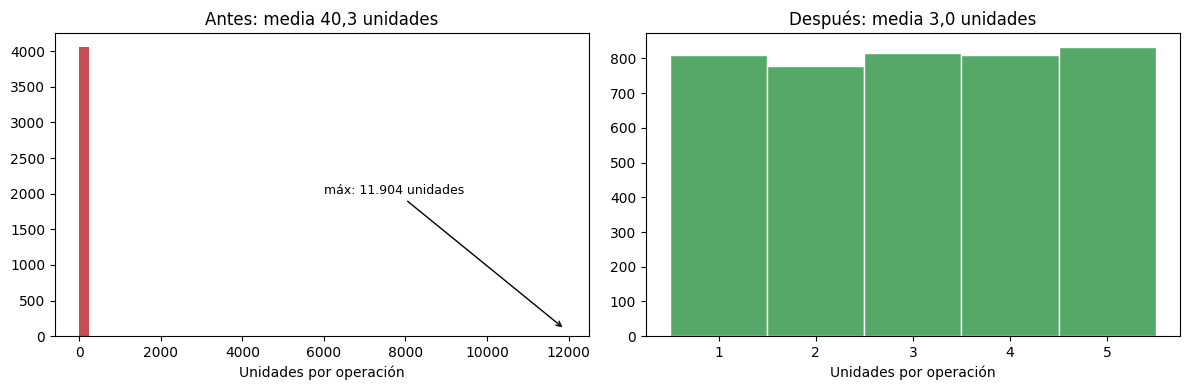

In [30]:
import matplotlib.pyplot as plt

# Unidades del conjunto original, convertidas a número pero sin depurar
unidades_sucias = pd.to_numeric(df_original["unidades_vendidas"], errors="coerce")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Antes
axes[0].hist(unidades_sucias.dropna(), bins=50, color="#c44e52")
axes[0].set_title("Antes: media 40,3 unidades")
axes[0].set_xlabel("Unidades por operación")
axes[0].annotate("máx: 11.904 unidades", xy=(11904, 100), xytext=(6000, 2000),
                 arrowprops=dict(arrowstyle="->"), fontsize=9)

# Después
axes[1].hist(df["unidades_vendidas"].dropna(),
             bins=[0.5, 1.5, 2.5, 3.5, 4.5, 5.5],
             color="#55a868", edgecolor="white")
axes[1].set_title("Después: media 3,0 unidades")
axes[1].set_xlabel("Unidades por operación")
axes[1].set_xticks([1, 2, 3, 4, 5])

plt.tight_layout()
plt.show()

---


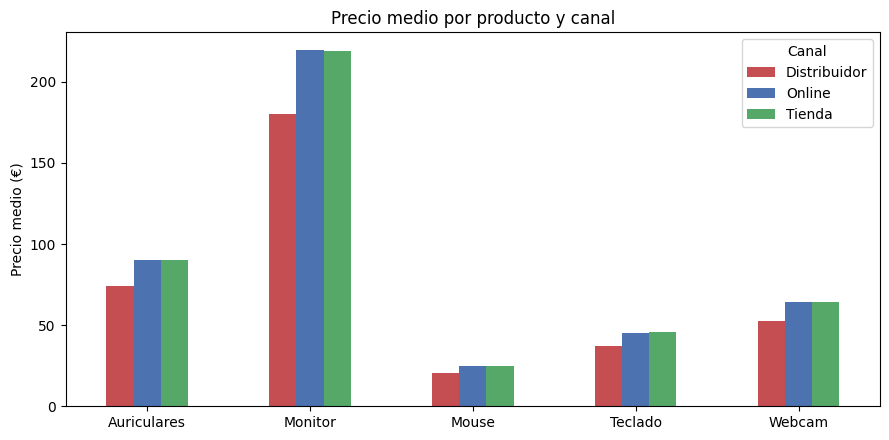

In [31]:
precio_canal[["Distribuidor", "Online", "Tienda"]].plot(
    kind="bar",
    figsize=(9, 4.5),
    color=["#c44e52", "#4c72b0", "#55a868"]
)

plt.title("Precio medio por producto y canal")
plt.ylabel("Precio medio (€)")
plt.xlabel("")
plt.xticks(rotation=0)
plt.legend(title="Canal")
plt.tight_layout()
plt.show()

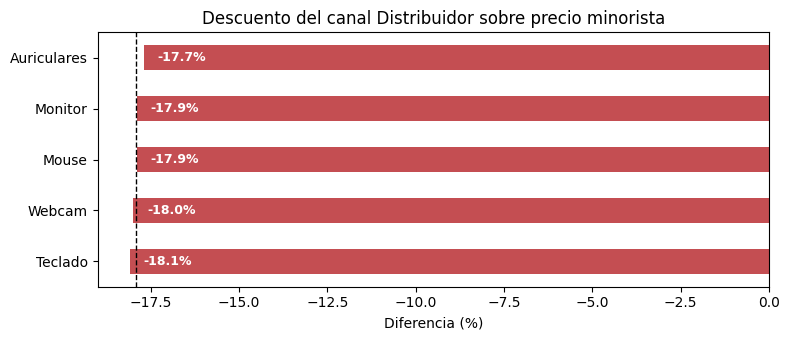

In [34]:
descuentos = precio_canal["descuento_distribuidor_%"].sort_values()

ax = descuentos.plot(kind="barh", figsize=(8, 3.5), color="#c44e52")
ax.set_title("Descuento del canal Distribuidor sobre precio minorista")
ax.set_xlabel("Diferencia (%)")
ax.set_ylabel("")
ax.axvline(descuentos.mean(), color="black", linestyle="--", linewidth=1)
for i, v in enumerate(descuentos):
    ax.text(v + 0.4, i, f"{v}%", va="center", ha="left",
            fontsize=9, color="white", fontweight="bold")    
plt.tight_layout()
plt.show()

### Estructura de precios por canal

El primer gráfico muestra el precio medio de cada producto según el canal. La
diferencia del canal Distribuidor es visible en los cinco productos, si bien la
escala absoluta la disimula en los artículos de menor precio: el descuento sobre
el ratón es el mayor del catálogo en términos relativos y el menos perceptible
en el gráfico.

El segundo gráfico corrige esa distorsión al representar la diferencia en
términos porcentuales. Las cinco barras convergen en torno a la media (línea
discontinua) con una dispersión inferior a medio punto, lo que confirma la
existencia de una tarifa mayorista aplicada de forma uniforme y no de acuerdos
negociados individualmente.

Ambas representaciones son necesarias: la primera sitúa la magnitud del
negocio, la segunda revela el patrón. Una sola de ellas conduciría a una
lectura incompleta.

---


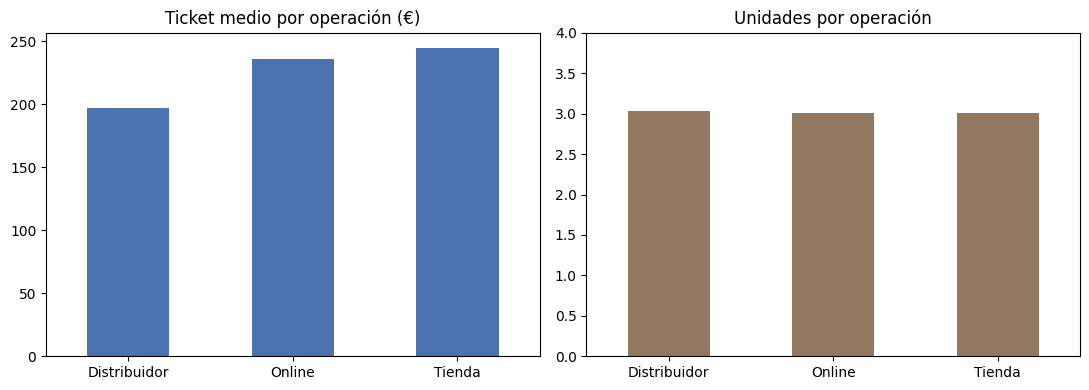

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Ticket medio: sí hay diferencia
resumen_canal["ticket_medio"].plot(kind="bar", ax=axes[0], color="#4c72b0")
axes[0].set_title("Ticket medio por operación (€)")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=0)

# Unidades por operación: no hay diferencia
resumen_canal["unidades_por_operacion"].plot(kind="bar", ax=axes[1], color="#937860")
axes[1].set_title("Unidades por operación")
axes[1].set_xlabel("")
axes[1].set_ylim(0, 4)
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

### Ticket medio frente a volumen por operación

La comparación entre ambos indicadores responde a la pregunta que plantea la
estructura de precios: si el canal Distribuidor obtiene un descuento del 18%,
cabría esperar que adquiriese cantidades superiores por operación.

El gráfico de la izquierda muestra un ticket medio de 197 € en Distribuidor
frente a 236 € y 244 € en los canales minoristas. El de la derecha muestra que
las unidades por operación son equivalentes en los tres canales (3,03 frente a
3,01). La diferencia de ticket no responde, por tanto, a un patrón de compra
distinto, sino exclusivamente al precio aplicado.

**Nota sobre la escala.** El eje del segundo gráfico se fija entre 0 y 4 de
forma deliberada. Con escala automática, una diferencia de 0,02 unidades
generaría barras de alturas muy dispares y sugeriría una disparidad
inexistente. El eje iniciado en cero representa la magnitud real de la
diferencia.

## 11. Conclusiones

**Sobre la calidad del dato.** El archivo original resultaba inutilizable para
el análisis: seis de sus siete columnas se leían como texto y la columna de
cantidades presentaba una media de 40,27 unidades por operación frente a un
valor real de 3,02. Cualquier informe elaborado sin depuración previa habría
comunicado una cifra desviada en más de un 1.200%.

**Sobre el proceso.** Se depuraron 4.215 registros hasta obtener 4.055 válidos,
con una pérdida del 3,8% atribuible a duplicados y filas vacías. Los valores
imposibles se anularon en lugar de eliminarse, para no descartar los campos
correctos de esos mismos registros, y se recuperaron mediante la relación
`ingreso = unidades × precio` allí donde los campos restantes lo permitían.

**Sobre el negocio.** El canal Distribuidor opera con un descuento uniforme del
18% sin que el volumen por operación lo justifique: adquiere 3,03 unidades por
transacción frente a 3,01 en los canales minoristas. Se recomienda revisar las
condiciones de este canal antes de renovarlas.

**Limitaciones.** Los 60 registros sin fecha (1,5%) y los 72 sin región (1,8%)
se conservan como nulos y quedan excluidos de los análisis temporales y
geográficos respectivamente. El umbral de detección de precios anómalos se ha
fijado en tres veces la mediana de cada producto; en un encargo real debería
validarse con el cliente.

---

*Conjunto depurado exportado como `ventas_limpio.csv`.*

